# ***Assignment 4*** 
### Description: Create a program that calculates and visualizes trade balances between a country and its top trading partners

In [ ]:
# Import necessary libraries 
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

In [240]:
# Analysis per sectors

# # Import dataset exports
export_df = pd.read_csv('Export final.csv', encoding="UTF-8", sep=';')
export_df

#in the dataset names of the columns are the names of the sectors and in parenthesis the siglas of countries 


,Year,Commercial services (J-A),Goods-related services (J-A),Transport (J-A),Air transport (J-A),Travel (J-A),Financial services (J-A),"Telecommunications, computer, and information services (J-A)",Total (J-A),Commercial services (J-C),...,"Telecommunications, computer, and information services (J-T)",Total (J-T),Commercial services (J-USA),Goods-related services (J-USA),Transport (J-USA),Air transport (J-USA),Travel (J-USA),Financial services (J-USA),"Telecommunications, computer, and information services (J-USA)",Total (J-USA)
0,2015,2363,39,547,103,659,245,13,3969,19684,...,44,15353,37525,318,7194,1617,1402,2858,1141,52055
1,2016,2652,26,563,160,906,274,40,4621,20722,...,51,15378,40640,403,6379,1694,1881,3378,1320,55695
2,2017,2833,25,639,182,938,287,91,4995,22669,...,72,15366,42162,411,6161,1576,2100,3485,1595,57490
3,2018,2887,26,484,148,1213,305,84,5147,25967,...,67,15769,40604,429,4665,1747,2623,3649,1503,55220
4,2019,3057,22,363,100,1404,392,128,5466,28994,...,52,14943,45049,448,4144,1734,3038,4056,2958,61427


In [241]:
# Import dataset imports
import_df = pd.read_csv('Import final.csv', encoding="UTF-8", sep=';')
import_df

,Year,Commercial services (J-A),Goods-related services (J-A),Transport (J-A),Air transport (J-A),Travel (J-A),Financial services (J-A),"Telecommunications, computer, and information services (J-A)",Total (J-A),Commercial services (J-C),...,"Telecommunications, computer, and information services (J-T)",Total (J-T),Commercial services (J-USA),Goods-related services (J-USA),Transport (J-USA),Air transport (J-USA),Travel (J-USA),Financial services (J-USA),"Telecommunications, computer, and information services (J-USA)",Total (J-USA)
0,2015,2100,149,761,237,134,167,122,3673,10745,...,312,9594,53425,1508,6438,2120,4750,2373,3698,74312
1,2016,2009,168,793,278,185,165,97,3696,10431,...,391,10791,56638,2012,6437,2031,5012,2379,4386,78895
2,2017,2239,248,787,301,140,193,92,4001,9950,...,350,10157,59060,2198,6833,2102,5223,2816,4137,82369
3,2018,2405,332,723,299,258,161,108,4288,11157,...,360,10502,60756,2017,4918,2027,6027,2939,5427,84111
4,2019,2340,385,538,275,376,141,107,4169,12142,...,397,11215,64723,3585,3185,1889,5756,3096,7245,89479


In [242]:
#merge the two datasets
merged_df = pd.merge(export_df, import_df, on='Year', how='inner')
merged_df 

,Year,Commercial services (J-A)_x,Goods-related services (J-A)_x,Transport (J-A)_x,Air transport (J-A)_x,Travel (J-A)_x,Financial services (J-A)_x,"Telecommunications, computer, and information services (J-A)_x",Total (J-A)_x,Commercial services (J-C)_x,...,"Telecommunications, computer, and information services (J-T)_y",Total (J-T)_y,Commercial services (J-USA)_y,Goods-related services (J-USA)_y,Transport (J-USA)_y,Air transport (J-USA)_y,Travel (J-USA)_y,Financial services (J-USA)_y,"Telecommunications, computer, and information services (J-USA)_y",Total (J-USA)_y
0,2015,2363,39,547,103,659,245,13,3969,19684,...,312,9594,53425,1508,6438,2120,4750,2373,3698,74312
1,2016,2652,26,563,160,906,274,40,4621,20722,...,391,10791,56638,2012,6437,2031,5012,2379,4386,78895
2,2017,2833,25,639,182,938,287,91,4995,22669,...,350,10157,59060,2198,6833,2102,5223,2816,4137,82369
3,2018,2887,26,484,148,1213,305,84,5147,25967,...,360,10502,60756,2017,4918,2027,6027,2939,5427,84111
4,2019,3057,22,363,100,1404,392,128,5466,28994,...,397,11215,64723,3585,3185,1889,5756,3096,7245,89479


# **TRADE BALANCES: exports - imports**

### For every sector we show the differences of trade balances across countries

In [243]:
#From merged_df we create a new table with columns whose values are differences between exp and imp (Commercial Services (J-A)_x - Commercial Services (J-A)_y) and so on for other sectors

# Get all columns that are exports and imports (ending with _x and _y)

#List of all column names in merged_df that end with '_x'
export_cols = [col for col in merged_df.columns if col.endswith('_x')]

#List of all column names in merged_df that end with '_y'
import_cols = [col for col in merged_df.columns if col.endswith('_y')]

# Get the base names (without _x or _y) removing the last two characters (col(-2:)) and checking if there is a corresponding import column ending with _y
base_names = [col[:-2] for col in export_cols if col[:-2] + '_y' in import_cols]

# We calculate trade balance for each sector-country pair
#In the for loop each 'base' is a string representing a sector-country pair, for each base it calculates the trade balance subtracting import column (base + '_y') from export column (base + '_x')
trade_balance_cols = {}
for base in base_names:
    trade_balance_cols[base] = merged_df[base + '_x'] - merged_df[base + '_y']

# Create a new DataFrame with the trade balances
trade_balance_df = pd.DataFrame(trade_balance_cols, index=merged_df.index)

# We show the new table
trade_balance_df.head()

,Commercial services (J-A),Goods-related services (J-A),Transport (J-A),Air transport (J-A),Travel (J-A),Financial services (J-A),"Telecommunications, computer, and information services (J-A)",Total (J-A),Commercial services (J-C),Goods-related services (J-C),...,"Telecommunications, computer, and information services (J-T)",Total (J-T),Commercial services (J-USA),Goods-related services (J-USA),Transport (J-USA),Air transport (J-USA),Travel (J-USA),Financial services (J-USA),"Telecommunications, computer, and information services (J-USA)",Total (J-USA)
0,263,-110,-214,-134,525,78,-109,296,8939,-1170,...,-268,5759,-15900,-1190,756,-503,-3348,485,-2557,-22257
1,643,-142,-230,-118,721,109,-57,925,10291,-975,...,-340,4587,-15998,-1609,-58,-337,-3131,999,-3066,-23200
2,594,-223,-148,-119,798,94,-1,994,12719,-908,...,-278,5209,-16898,-1787,-672,-526,-3123,669,-2542,-24879
3,482,-306,-239,-151,955,144,-24,859,14810,-1025,...,-293,5267,-20152,-1588,-253,-280,-3404,710,-3924,-28891
4,717,-363,-175,-175,1028,251,21,1297,16852,-947,...,-345,3728,-19674,-3137,959,-155,-2718,960,-4287,-28052


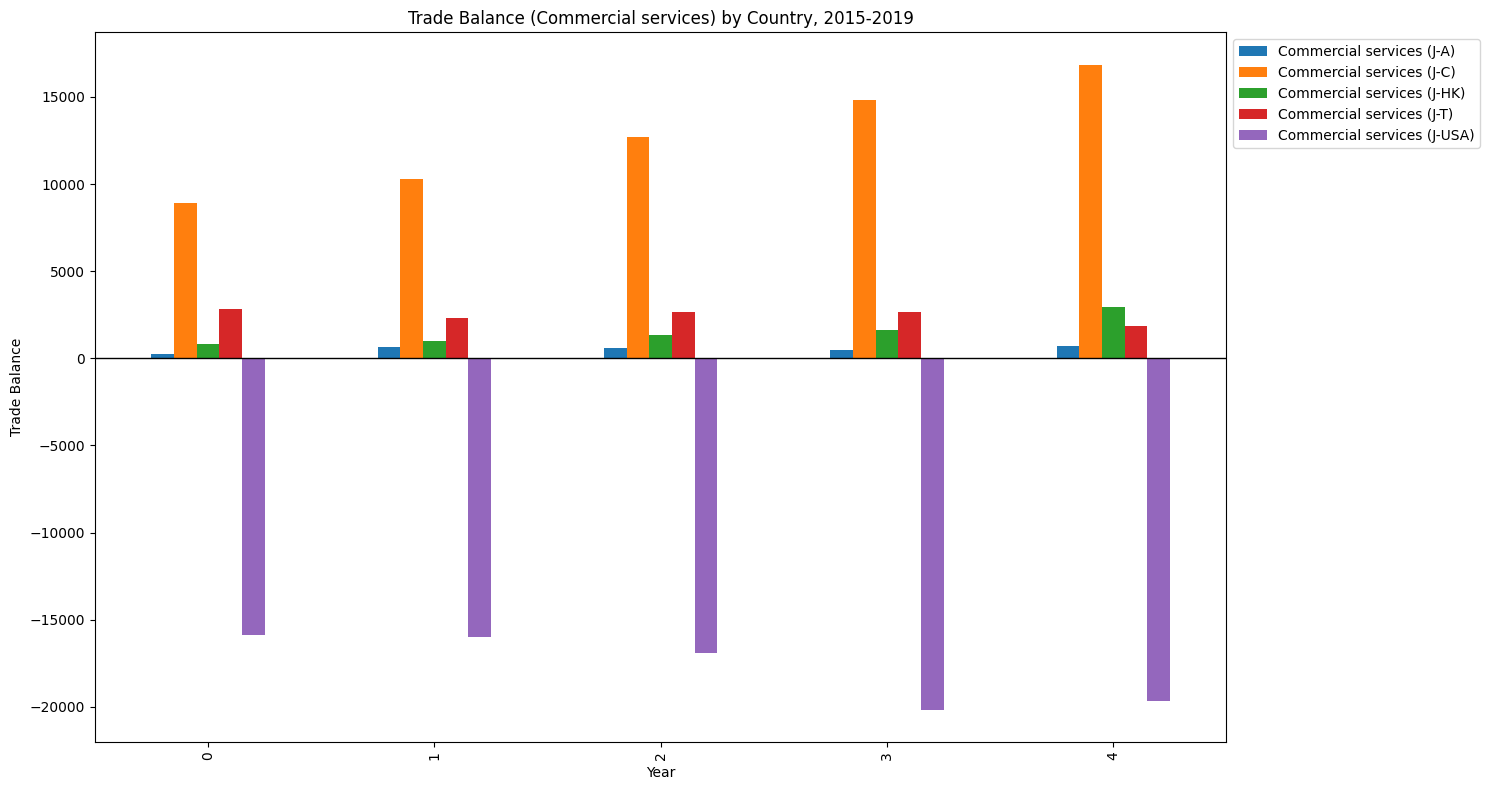

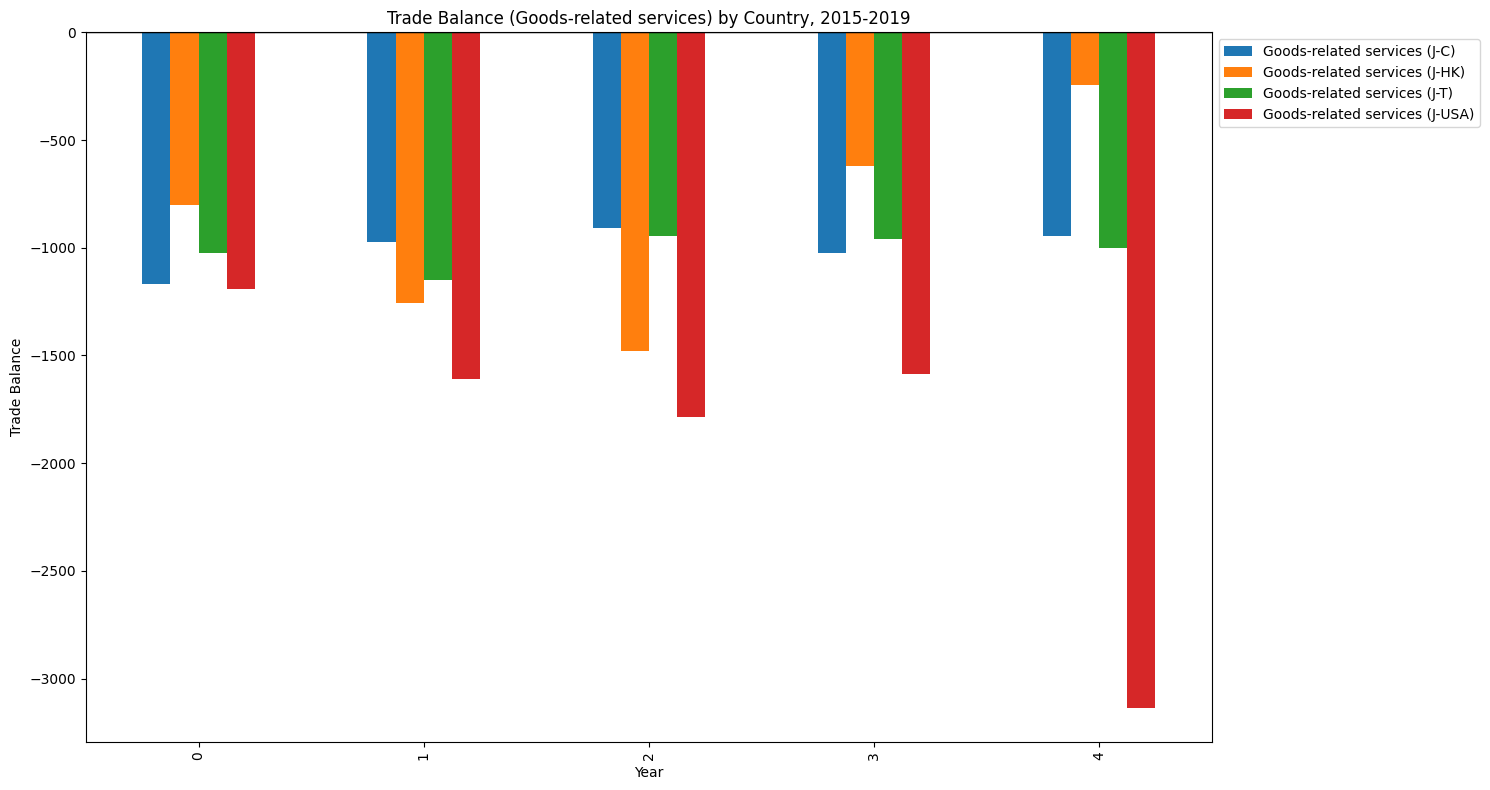

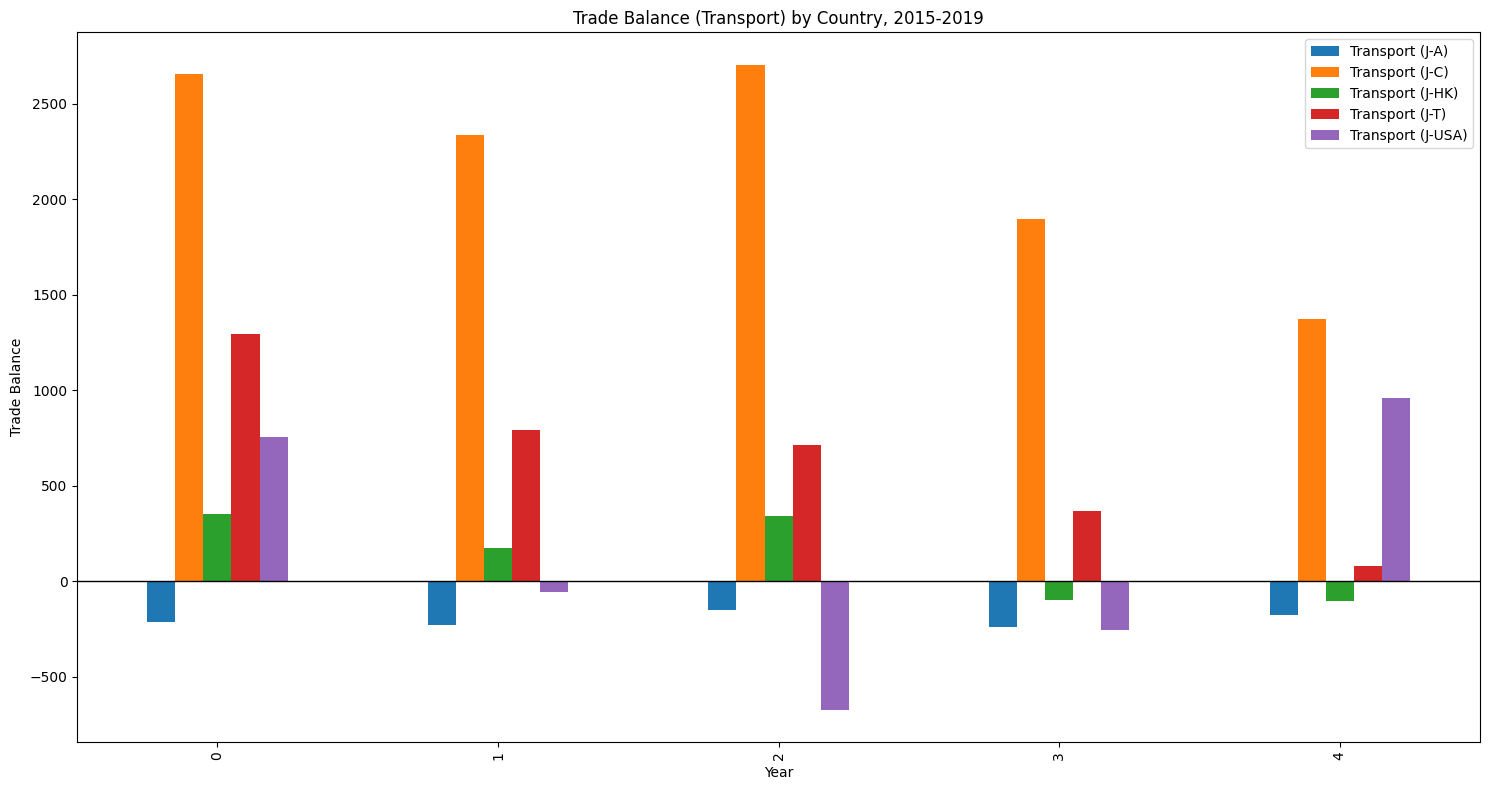

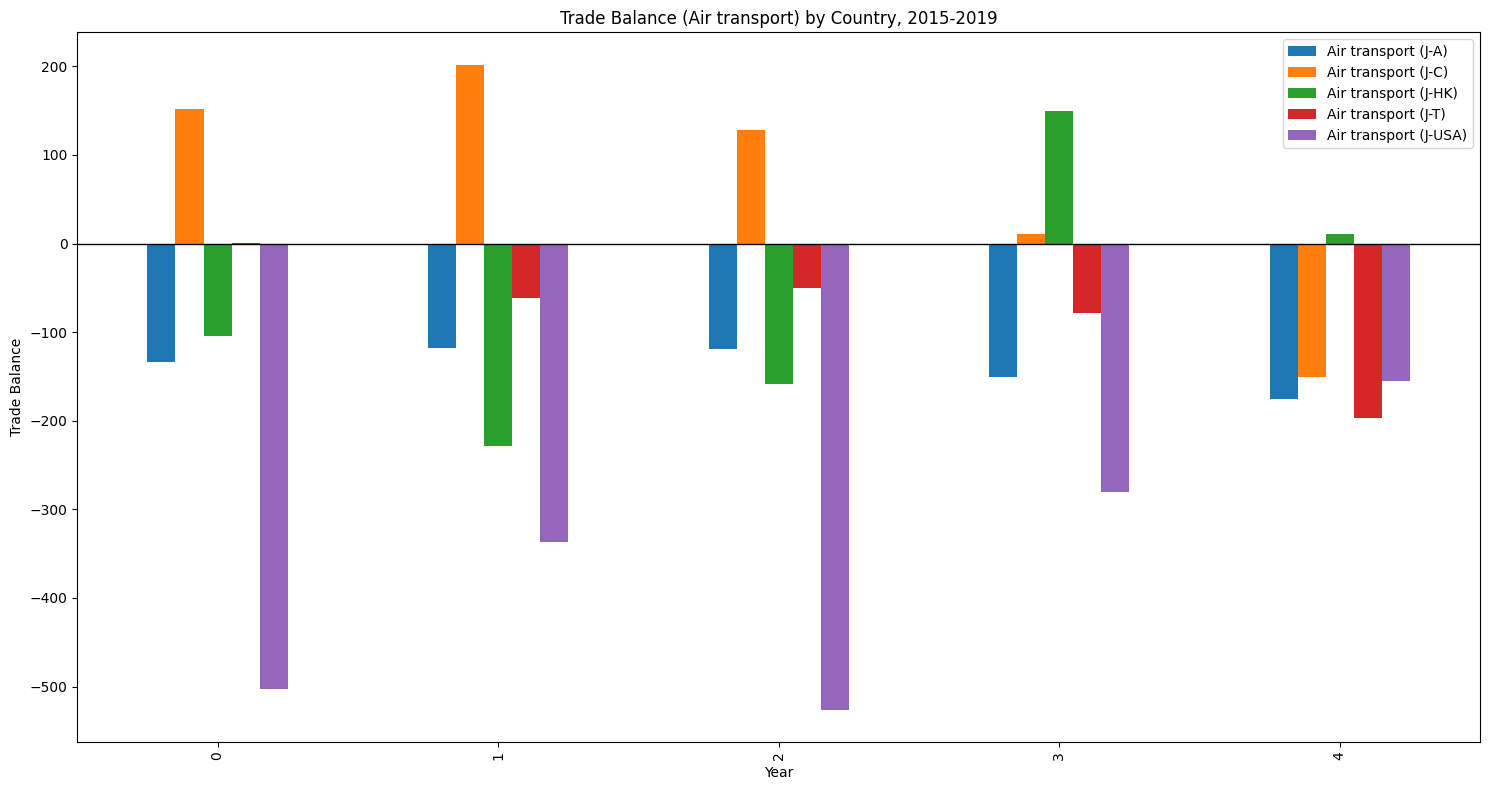

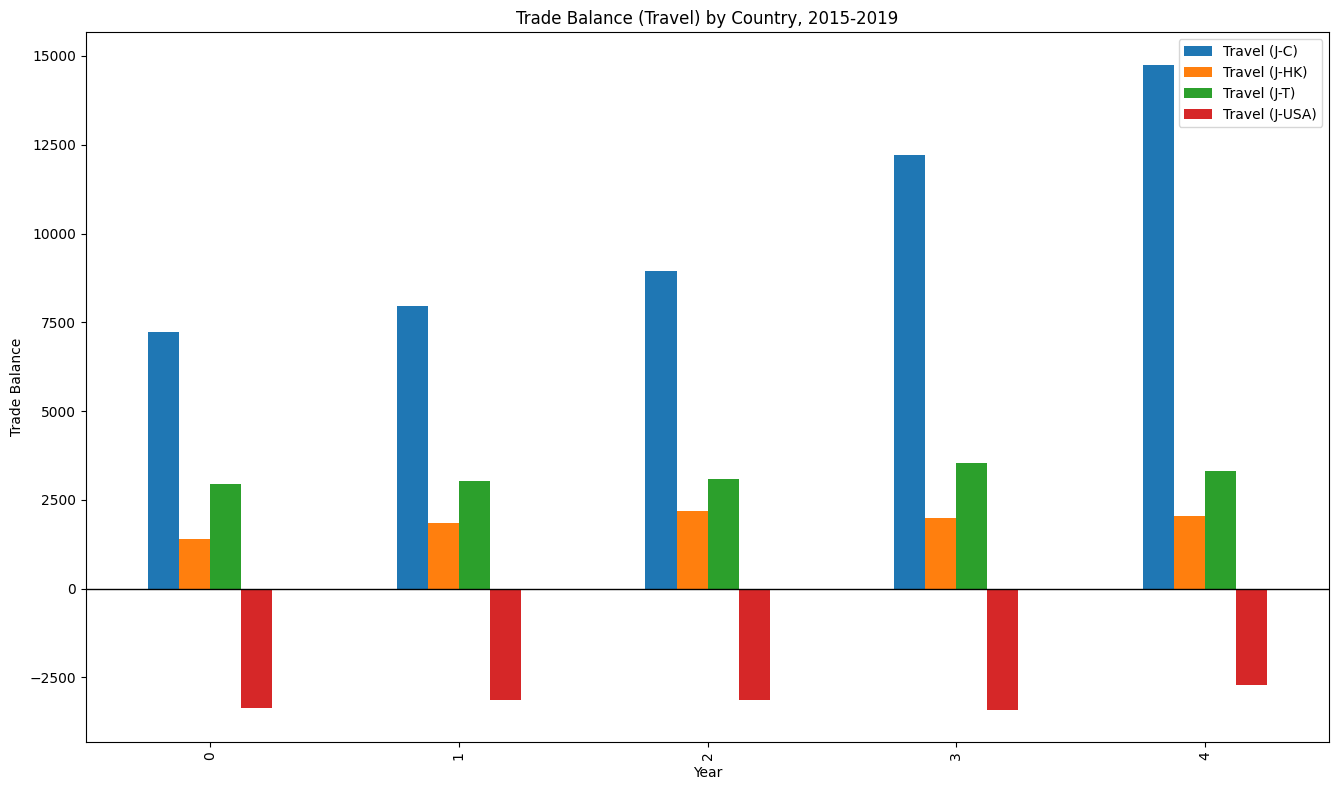

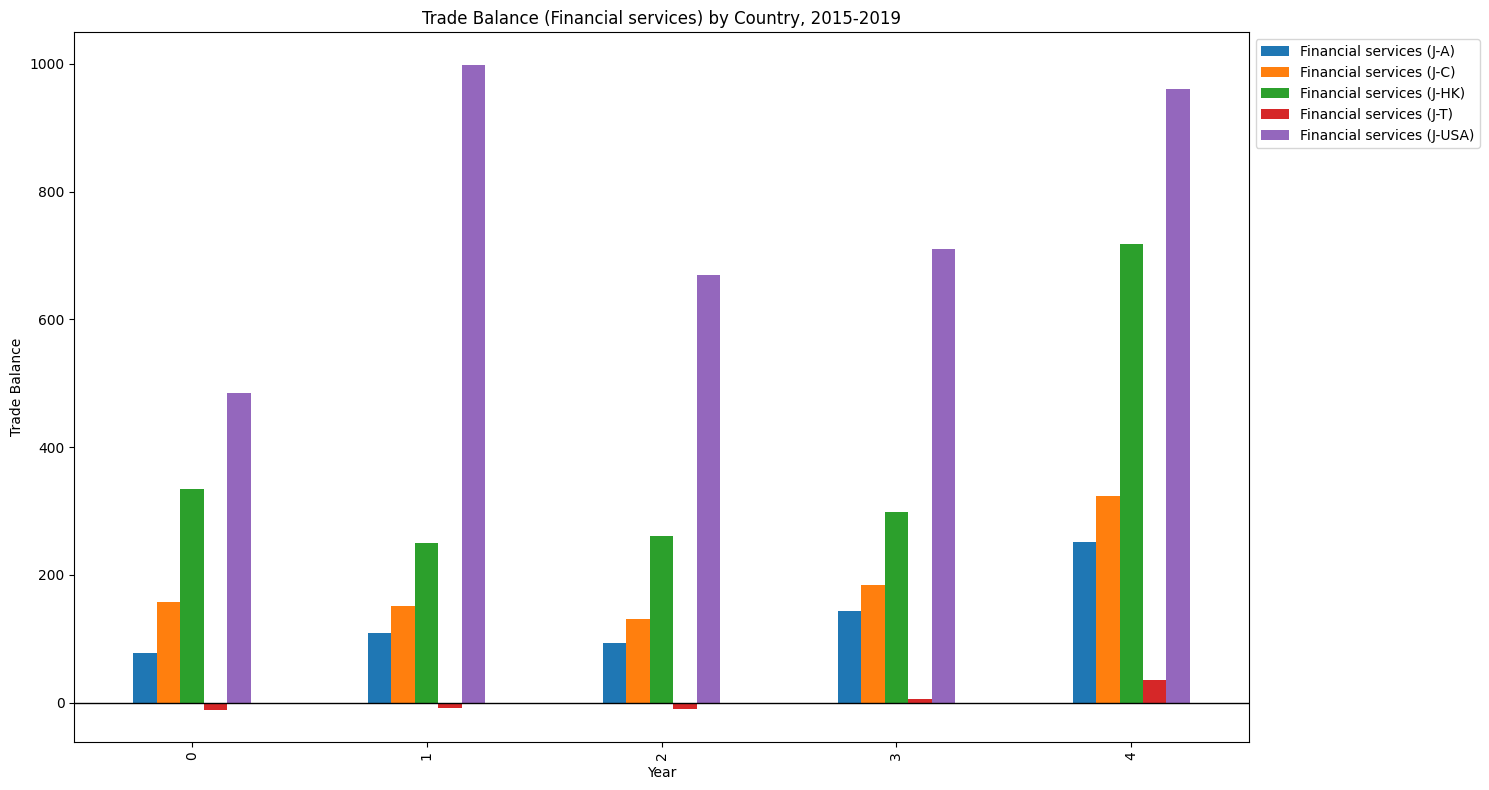

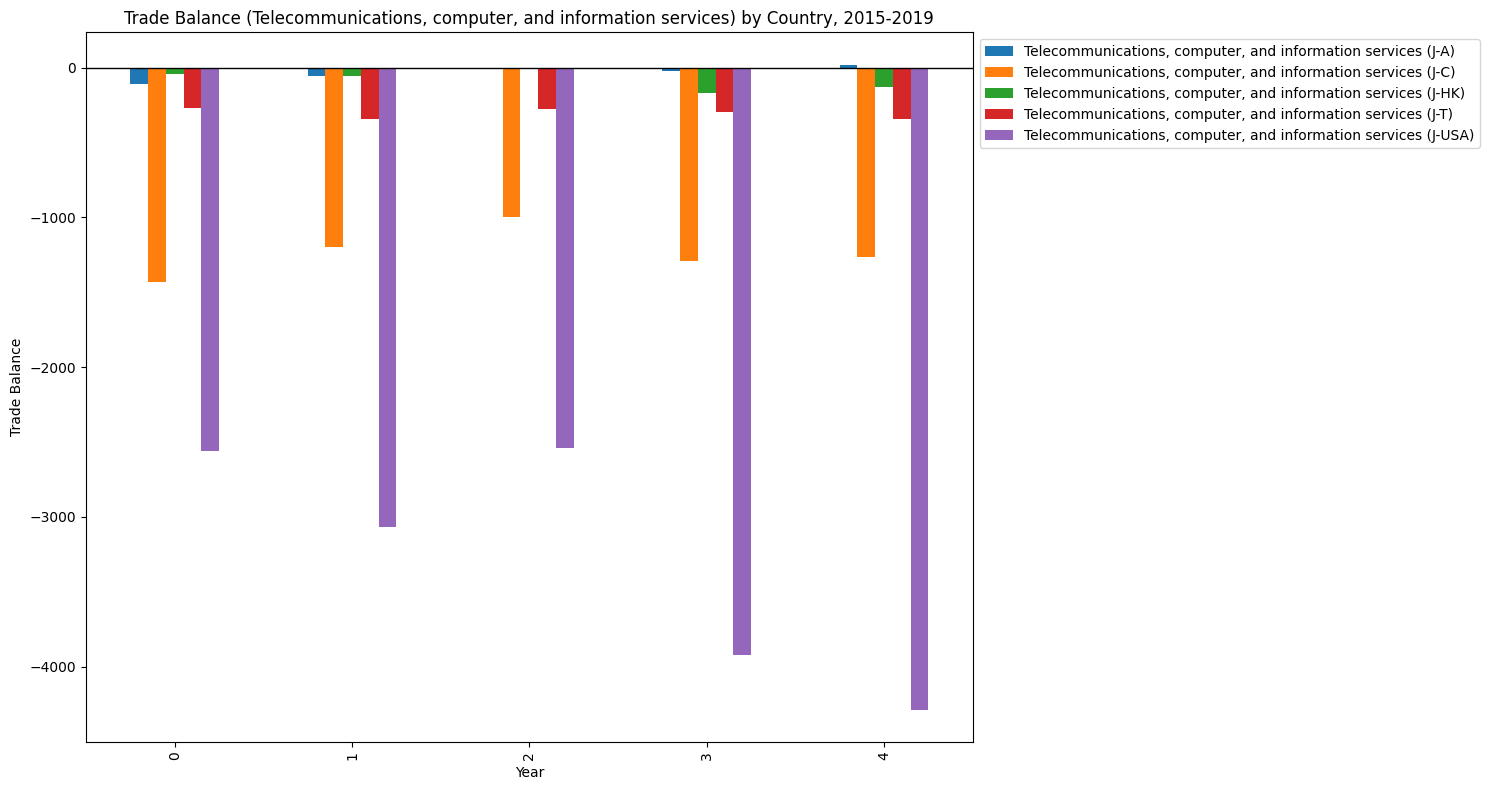

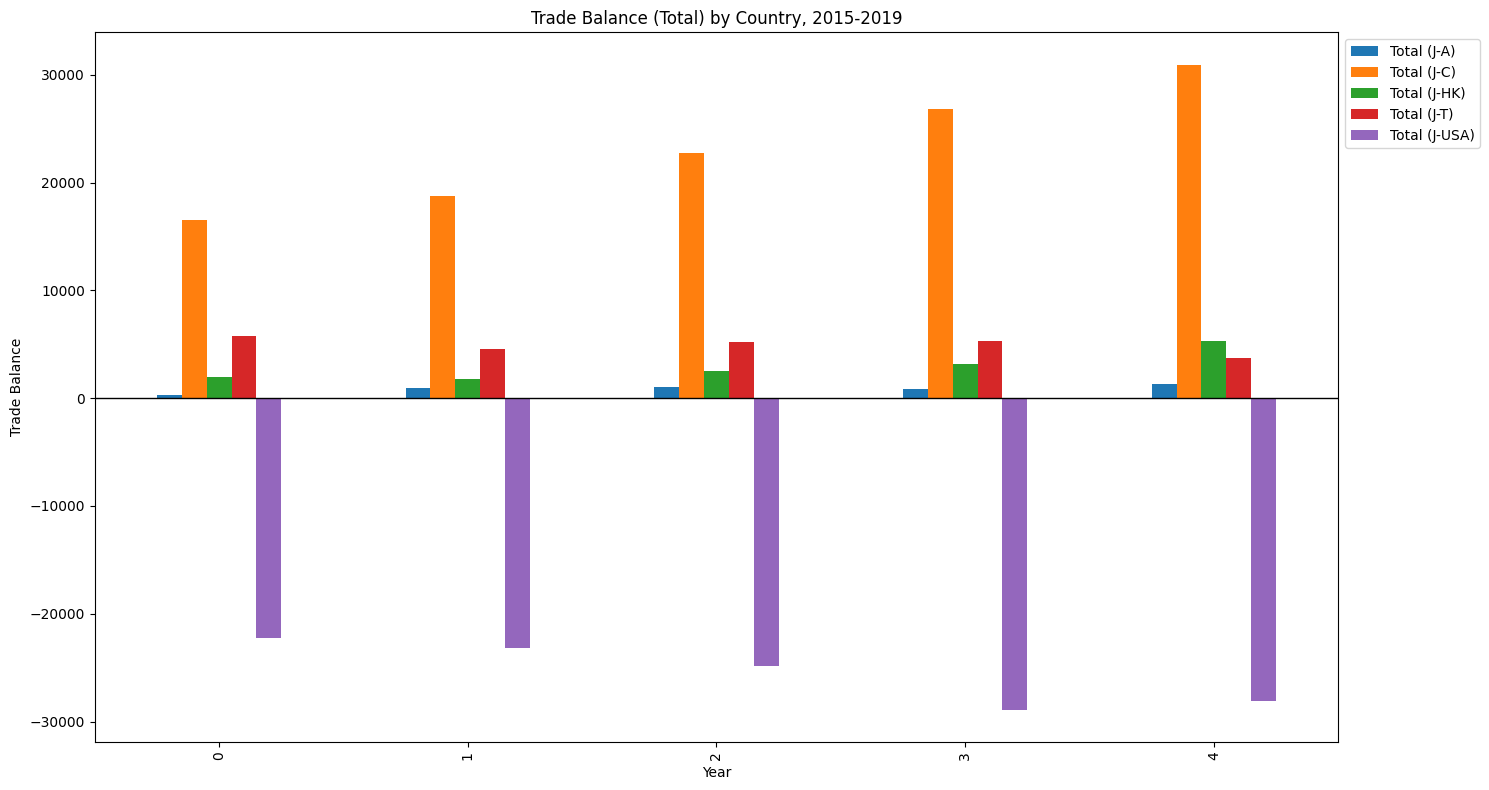

In [244]:
#Since we have 7 sectors, we will create 7 different graphs, one for each sector 
#Then we'll add one graph for the total

# List of unique sectors (excluding 'Total' if present)
sectors = []
for col in trade_balance_df.columns:
    sector = col.split('(')[0].strip()
    if sector not in sectors:
        sectors.append(sector)

# Plot for each sector (bar chart per year, one plot per sector)
for sector in sectors:
    sector_cols = [col for col in trade_balance_df.columns if col.startswith(sector)]
    if not sector_cols:
        continue
    plt.figure(figsize=(15,8))
    trade_balance_df[sector_cols].plot(kind='bar', ax=plt.gca()) #plt.gca() gets the current axes, and we plot the trade balance for each sector
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f"Trade Balance ({sector}) by Country, 2015-2019")
    plt.ylabel('Trade Balance')
    plt.xlabel('Year')
    plt.legend(loc='best', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()


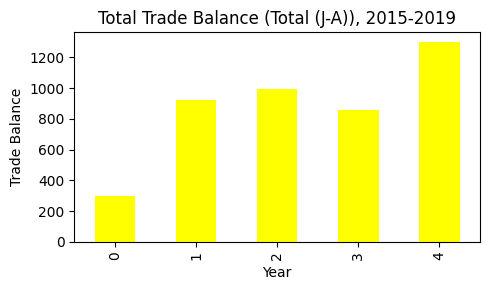

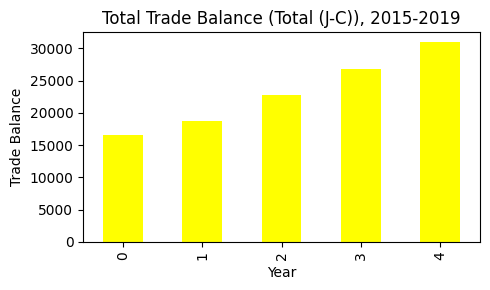

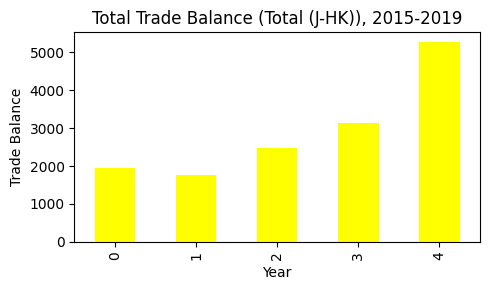

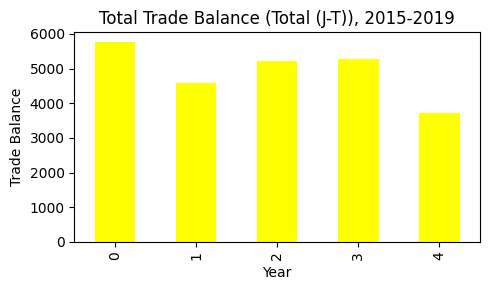

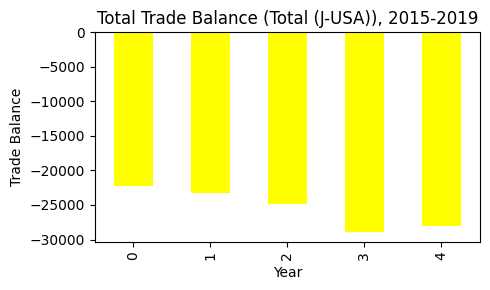

In [245]:
# Focusing on the plot for the total trade balance we will create separate plots for each pair of countries

# Find all columns that contain 'total' (case-insensitive)
total_cols = [col for col in trade_balance_df.columns if 'total' in col.lower()]

# Plot each 'Total' column found
for total_col in total_cols:
    plt.figure(figsize=(5,3))
    trade_balance_df[total_col].plot(kind='bar', color='yellow')
    plt.title(f"Total Trade Balance ({total_col}), 2015-2019")
    plt.ylabel('Trade Balance')
    plt.xlabel('Year')
    plt.tight_layout()
    plt.show()

# **TRADE OPENNESS**

### We calculate it as the ratio of a country's total trade to the country's gross domestic product


In [246]:
# Import dataset GDP
gdp_df = pd.read_csv('Japan GDP.csv', encoding="UTF-8", sep=';')
gdp_df

,Time,GDP (current US$)
0,2015,4444930651964
1,2016,5003677627544
2,2017,4930837369151
3,2018,5040880939324
4,2019,5117993853016


In [254]:
# Total trade balance in the years 2015-2019

# Import dataset 
totaltrade_df = pd.read_csv('ExpimpTotal.csv', encoding="UTF-8", sep=';')
totaltrade_df 

# Create a new column whose values are the difference between exports and imports
totaltrade_df['Trade Balance'] = totaltrade_df['Total Exports (J-W)'] + totaltrade_df['Total Imports (J-W)']
totaltrade_df['Trade Balance']
totaltrade_df.head()



,Time,Total Imports (J-W),Total Exports (J-W),Trade Balance
0,2015,799671850412,775051882733,1574723733145
1,2016,763174802439,803489014103,1566663816542
2,2017,829947425329,867405253150,1697352678479
3,2018,922228472389,923234601724,1845463074113
4,2019,908591904961,893782209080,1802374114041


In [255]:
# From tradebalance_df and gdp_df we create a new table with columns whose values are the percentage ratio between the trade balance and the GDP 

# Strip any leading or trailing spaces from column names in gdp_df
gdp_df.columns = gdp_df.columns.str.strip()

# Calculate trade openness as a percentage of GDP
trade_openness_percent = (totaltrade_df['Trade Balance'] / gdp_df['GDP (current US$)']) * 100

# Add the result as a new column
merged_df['Trade Openness (%)'] = trade_openness_percent

# Show the result
merged_df[['Trade Openness (%)']]

,Trade Openness (%)
0,35.427408
1,31.310247
2,34.423214
3,36.609932
4,35.216418


In [215]:
# Convert Year column to int
merged_df['Year'] = merged_df['Year'].astype(int)


<function matplotlib.pyplot.show(close=None, block=None)>

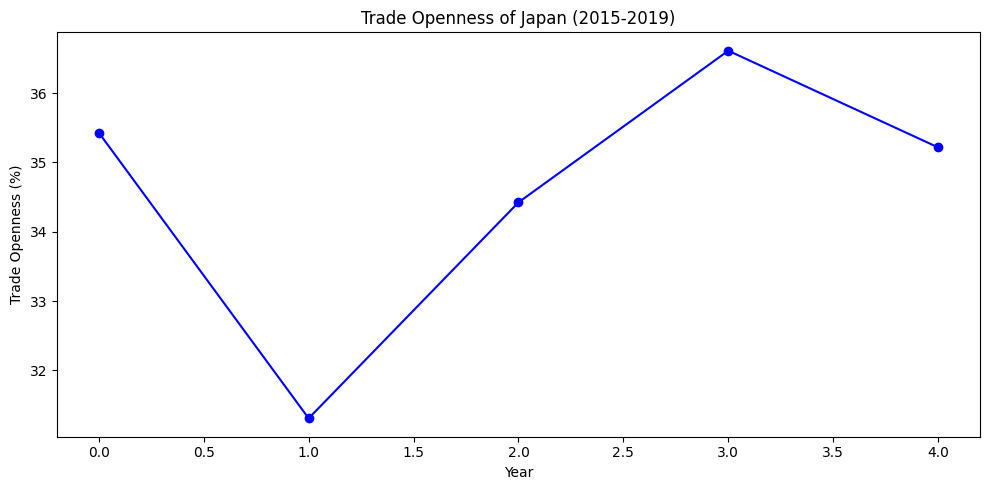

In [ ]:
# We will plot the TRADE OPENNESS of Japan for the years 2015-2019
plt.figure(figsize=(10, 5))
plt.plot(merged_df['Trade Openness (%)'], marker='o', color='blue')
plt.title('Trade Openness of Japan (2015-2019)')
plt.xlabel('Year')
plt.ylabel('Trade Openness (%)')
plt.tight_layout() 
plt.show 

# **EXPORT/IMPORT RATIO**

### We calculate it as the ratio between exports and imports